In [14]:
exp_name = 'gmd_radiative_convective_1420w_10min_v3'
exp_folder_name = 'column_code_with_slab'
model_name = 'mlp_v2'   # 'mlp' 'mlp_v2' or 'lstm' or 'trsfm_v2_Tw_20'
best_trial_number = '0'
emulate = 'conv'       # 'conv' or 'rad'
emulate_layer = 28

ml_exp_name = 'best_model' + '_' + emulate + '_' + model_name
best_model_path = f"./{exp_folder_name}/{ml_exp_name}/trial_{best_trial_number}.pth"

# ----------------- dims -----------------
if exp_folder_name == 'gmd_aquaplanet' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
if exp_folder_name == 'gmd_aquaplanet' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59-(28-emulate_layer)*2, 57-(28-emulate_layer)*2
if exp_folder_name == 'column_code_with_slab' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
if exp_folder_name == 'column_code_with_slab' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59-(28-emulate_layer)*2, 57-(28-emulate_layer)*2

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import sys, os
sys.path.append("..")
import numpy as np
from models import (
    DynamicMLP_flatten,
    DynamicMLP_flatten_v2,
    WindowTemporalLSTM,
    WindowTemporalTransformer,
    WindowTemporalTransformer_v2,
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(best_model_path, map_location="cpu")
BATCH_SIZE = ckpt["batch_size"]

# Tw is only needed for windowed models
Tw = int(ckpt["T_window"]) if ("T_window" in ckpt) else None

# ----------------- load test data -----------------
X_test = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_test.pth",
    weights_only=True
)
y_test = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_test.pth",
    weights_only=True
)
norm = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth",
    weights_only=True
)

X_max = norm['X_max']
X_min = norm['X_min']
y_mean = norm['y_mean']
y_std  = norm['y_std']

X_den = (X_max - X_min).clone()
X_den[X_den == 0.0] = 1.0
y_std_safe = y_std.clone()
y_std_safe[y_std_safe == 0.0] = 1.0

# normalize
X_test_n = (X_test - X_min) / X_den
y_test_n = (y_test - y_mean) / y_std_safe

# ----------------- window helper -----------------
def make_windows_test(Xn, yn, Xraw, yraw, Tw):
    """
    For 2D [N, C] tensors:
      unfold -> [N2, C, Tw]
      permute -> [N2, Tw, C]
    Targets are aligned to last time in each window: y[t] where t is window end.
    """
    if Tw is None:
        raise ValueError("Tw is None.")
    if Tw < 1:
        raise ValueError(f"Tw must be >= 1, got {Tw}")
    if Xn.shape[0] < Tw:
        raise ValueError(f"N={Xn.shape[0]} is smaller than Tw={Tw}")

    Xn_w   = Xn.unfold(0, Tw, 1).permute(0, 2, 1).contiguous()    # [N2, Tw, C]
    Xraw_w = Xraw.unfold(0, Tw, 1).permute(0, 2, 1).contiguous()  # [N2, Tw, C]
    yn_w   = yn[Tw-1:].contiguous()                                # [N2, O]
    yraw_w = yraw[Tw-1:].contiguous()                              # [N2, O]
    return Xn_w, yn_w, Xraw_w, yraw_w

# ----------------- dataset / loader -----------------
if "mlp" in model_name:
    test_set = TensorDataset(X_test_n, y_test_n, X_test, y_test)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

elif ("lstm" in model_name) or ("trsfm" in model_name):
    if Tw is None:
        raise ValueError(f"{model_name} checkpoint missing T_window.")
    Xw_test_n, yw_test_n, Xw_test, yw_test = make_windows_test(X_test_n, y_test_n, X_test, y_test, Tw)
    test_set = TensorDataset(Xw_test_n, yw_test_n, Xw_test, yw_test)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

else:
    raise ValueError(f"Unknown model_name={model_name}")

# ----------------- load model -----------------
if model_name == "mlp":
    model = DynamicMLP_flatten(IN_FEATURES, OUT_FEATURES, ckpt["hidden_sizes"]).to(device)
if model_name == "mlp_v2":
    model = DynamicMLP_flatten_v2(IN_FEATURES, OUT_FEATURES, ckpt["hidden_sizes"]).to(device)
if model_name == "lstm":
    model = WindowTemporalLSTM(
        C_in=IN_FEATURES,
        C_out=OUT_FEATURES,
        T_window=Tw,
        hidden_size=ckpt["hidden_size"],
        num_layers=ckpt["num_layers"],
        dropout=ckpt["dropout"],
        nlev=int(ckpt.get("nlev", emulate_layer)),
    ).to(device)
if "trsfm_v2" in model_name:
    model = WindowTemporalTransformer_v2(
        C_in=IN_FEATURES,
        C_out=OUT_FEATURES,
        T_window=Tw,
        d_model=ckpt["d_model"],
        nhead=ckpt["nhead"],
        num_layers=ckpt["num_layers"],
        dim_feedforward=ckpt["dim_feedforward"],
        dropout=ckpt["dropout"],
        causal=True,
        # load constraint metadata saved in training
        nlev=int(ckpt.get("nlev", emulate_layer)),
        clamp_from_level=ckpt.get("clamp_from_level", None),
        input_clamp_from_level=ckpt.get("input_clamp_from_level", None),
    ).to(device)
    
model.load_state_dict(ckpt["model_state"])
model.eval()

# ----------------- inference -----------------
pred_n_list = []
yraw_list = []

with torch.no_grad():
    for Xn, yn, Xraw, yraw in test_loader:
        Xn = Xn.to(device)
        Xraw = Xraw.to(device)
        yraw = yraw.to(device)

        y_pred_n = model(Xn)
        
        pred_n_list.append(y_pred_n.cpu())
        yraw_list.append(yraw.cpu())

test_pred_n = torch.cat(pred_n_list, dim=0)   # normalized preds
y_true_raw  = torch.cat(yraw_list, dim=0)     # raw targets aligned to preds

# denorm preds to raw units
test_pred_raw = test_pred_n * y_std_safe + y_mean

loss_fn = nn.MSELoss()
print("Test raw MSE:", loss_fn(y_true_raw, test_pred_raw).item())

# ----------------- optional reshape for aquaplanet plotting -----------------
if exp_folder_name == 'gmd_aquaplanet':
    H, W = 32, 64
    if model_name == "mlp":
        B = X_test.shape[0] // (H * W)
        X_test_4d = X_test.reshape(B, H, W, IN_FEATURES).permute(0, 3, 1, 2)
        y_test_4d = y_test.reshape(B, H, W, OUT_FEATURES).permute(0, 3, 1, 2)
        pred_4d   = test_pred_raw.reshape(B, H, W, OUT_FEATURES).permute(0, 3, 1, 2)
    else:
        print(
            "Aquaplanet + windowed model: test length is N-Tw+1, "
            "so you cannot reshape to [B,H,W,...] unless you windowed per-gridpoint separately."
        )

Test raw MSE: 1.55904890561942e-05


In [1]:
exp_name = 'gmd_radiative_convective_1420w_10min_v3'
exp_folder_name = 'column_code_with_slab'
model_names = ['mlp', 'mlp_v2', 'lstm']   # add more here
best_trial_numbers = {
    'mlp': '0',
    'mlp_v2': '0',
    'lstm': '0',
    # 'trsfm_v2_Tw_20': '0',
}
emulate = 'conv'       # 'conv' or 'rad'
emulate_layer = 28

# ----------------- dims -----------------
if exp_folder_name == 'gmd_aquaplanet' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
if exp_folder_name == 'gmd_aquaplanet' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59 - (28 - emulate_layer) * 2, 57 - (28 - emulate_layer) * 2
if exp_folder_name == 'column_code_with_slab' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
if exp_folder_name == 'column_code_with_slab' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59 - (28 - emulate_layer) * 2, 57 - (28 - emulate_layer) * 2

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import sys, os
sys.path.append("..")
import numpy as np
from models import (
    DynamicMLP_flatten,
    DynamicMLP_flatten_v2,
    WindowTemporalLSTM,
    WindowTemporalTransformer,
    WindowTemporalTransformer_v2,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------- load test data once -----------------
X_test = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_test.pth",
    weights_only=True
)
y_test = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_test.pth",
    weights_only=True
)
norm = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth",
    weights_only=True
)

X_max = norm['X_max']
X_min = norm['X_min']
y_mean = norm['y_mean']
y_std  = norm['y_std']

X_den = (X_max - X_min).clone()
X_den[X_den == 0.0] = 1.0
y_std_safe = y_std.clone()
y_std_safe[y_std_safe == 0.0] = 1.0

# normalize once
X_test_n = (X_test - X_min) / X_den
y_test_n = (y_test - y_mean) / y_std_safe

# ----------------- window helper -----------------
def make_windows_test(Xn, yn, Xraw, yraw, Tw):
    if Tw is None:
        raise ValueError("Tw is None.")
    if Tw < 1:
        raise ValueError(f"Tw must be >= 1, got {Tw}")
    if Xn.shape[0] < Tw:
        raise ValueError(f"N={Xn.shape[0]} is smaller than Tw={Tw}")

    Xn_w   = Xn.unfold(0, Tw, 1).permute(0, 2, 1).contiguous()    # [N2, Tw, C]
    Xraw_w = Xraw.unfold(0, Tw, 1).permute(0, 2, 1).contiguous()  # [N2, Tw, C]
    yn_w   = yn[Tw - 1:].contiguous()                              # [N2, O]
    yraw_w = yraw[Tw - 1:].contiguous()                            # [N2, O]
    return Xn_w, yn_w, Xraw_w, yraw_w

# ----------------- model factory -----------------
def build_model(model_name, ckpt, in_features, out_features, emulate_layer, device):
    Tw = int(ckpt["T_window"]) if ("T_window" in ckpt) else None

    if model_name == "mlp":
        model = DynamicMLP_flatten(
            in_features, out_features, ckpt["hidden_sizes"]
        ).to(device)

    elif model_name == "mlp_v2":
        model = DynamicMLP_flatten_v2(
            in_features,
            out_features,
            ckpt["hidden_sizes"],
            # nlev=int(ckpt.get("nlev", emulate_layer)),
            # clamp_from_level=ckpt.get("clamp_from_level", None),
            # input_clamp_from_level=ckpt.get("input_clamp_from_level", None),
        ).to(device)

    elif model_name == "lstm":
        model = WindowTemporalLSTM(
            C_in=in_features,
            C_out=out_features,
            T_window=Tw,
            hidden_size=ckpt["hidden_size"],
            num_layers=ckpt["num_layers"],
            dropout=ckpt["dropout"],
            nlev=int(ckpt.get("nlev", emulate_layer)),
        ).to(device)

    elif "trsfm_v2" in model_name:
        model = WindowTemporalTransformer_v2(
            C_in=in_features,
            C_out=out_features,
            T_window=Tw,
            d_model=ckpt["d_model"],
            nhead=ckpt["nhead"],
            num_layers=ckpt["num_layers"],
            dim_feedforward=ckpt["dim_feedforward"],
            dropout=ckpt["dropout"],
            causal=True,
            nlev=int(ckpt.get("nlev", emulate_layer)),
            clamp_from_level=ckpt.get("clamp_from_level", None),
            input_clamp_from_level=ckpt.get("input_clamp_from_level", None),
        ).to(device)

    elif "trsfm" in model_name:
        model = WindowTemporalTransformer(
            C_in=in_features,
            C_out=out_features,
            T_window=Tw,
            d_model=ckpt["d_model"],
            nhead=ckpt["nhead"],
            num_layers=ckpt["num_layers"],
            dim_feedforward=ckpt["dim_feedforward"],
            dropout=ckpt["dropout"],
            causal=True,
        ).to(device)

    else:
        raise ValueError(f"Unknown model_name={model_name}")

    return model, Tw

# ----------------- run all models -----------------
all_test_pred_raw = {}
all_test_pred_n = {}
all_y_true_raw = {}
all_mse = {}

loss_fn = nn.MSELoss()

for model_name in model_names:
    print(f"\n===== Running {model_name} =====")

    best_trial_number = best_trial_numbers[model_name]
    ml_exp_name = 'best_model' + '_' + emulate + '_' + model_name
    best_model_path = f"./{exp_folder_name}/{ml_exp_name}/trial_{best_trial_number}.pth"
    ckpt = torch.load(best_model_path, map_location="cpu")
    BATCH_SIZE = ckpt["batch_size"]

    model, Tw = build_model(
        model_name=model_name,
        ckpt=ckpt,
        in_features=IN_FEATURES,
        out_features=OUT_FEATURES,
        emulate_layer=emulate_layer,
        device=device
    )

    # ----------------- dataset / loader -----------------
    if "mlp" in model_name:
        test_set = TensorDataset(X_test_n, y_test_n, X_test, y_test)
    elif ("lstm" in model_name) or ("trsfm" in model_name):
        if Tw is None:
            raise ValueError(f"{model_name} checkpoint missing T_window.")
        Xw_test_n, yw_test_n, Xw_test, yw_test = make_windows_test(
            X_test_n, y_test_n, X_test, y_test, Tw
        )
        test_set = TensorDataset(Xw_test_n, yw_test_n, Xw_test, yw_test)
    else:
        raise ValueError(f"Unknown model_name={model_name}")

    test_loader = DataLoader(
        test_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
    )

    model.load_state_dict(ckpt["model_state"])
    model.eval()

    # ----------------- inference -----------------
    pred_n_list = []
    yraw_list = []

    with torch.no_grad():
        for Xn, yn, Xraw, yraw in test_loader:
            Xn = Xn.to(device)
            y_pred_n = model(Xn)

            pred_n_list.append(y_pred_n.cpu())
            yraw_list.append(yraw.cpu())

    test_pred_n = torch.cat(pred_n_list, dim=0)
    y_true_raw = torch.cat(yraw_list, dim=0)
    test_pred_raw = test_pred_n * y_std_safe + y_mean

    mse_val = loss_fn(y_true_raw, test_pred_raw).item()

    all_test_pred_n[model_name] = test_pred_n
    all_test_pred_raw[model_name] = test_pred_raw
    all_y_true_raw[model_name] = y_true_raw
    all_mse[model_name] = mse_val

    print(f"{model_name} Test raw MSE: {mse_val:.8f}")
    print(f"{model_name} pred shape: {tuple(test_pred_raw.shape)}")


===== Running mlp =====
mlp Test raw MSE: 0.00037937
mlp pred shape: (79863, 57)

===== Running mlp_v2 =====
mlp_v2 Test raw MSE: 0.00001559
mlp_v2 pred shape: (79863, 57)

===== Running lstm =====
lstm Test raw MSE: 0.00002506
lstm pred shape: (79854, 57)


# single-col

## conv

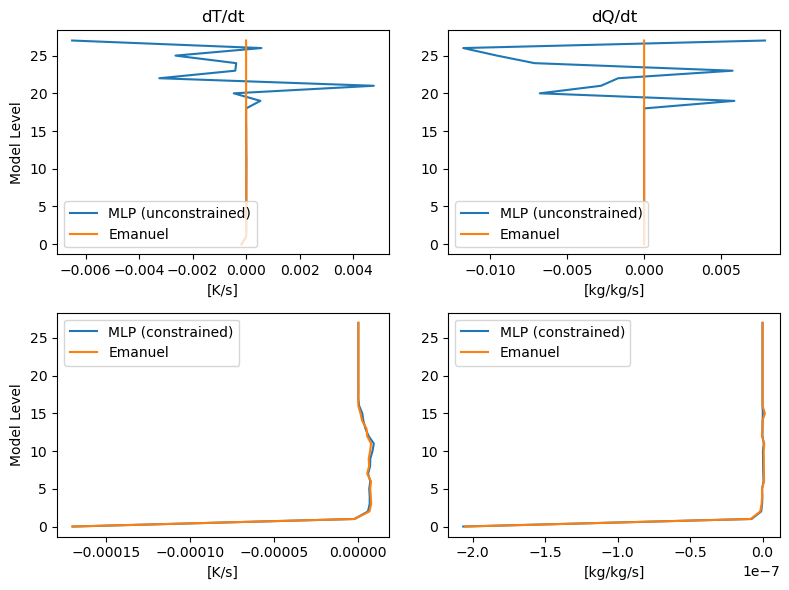

In [8]:
mlp_pred = all_test_pred_raw['mlp']
mlp_v2_pred = all_test_pred_raw['mlp_v2']

# assume same y_true for both
y_true = all_y_true_raw['mlp']

time_idx = -200

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=True)

# ----------------- TOP: MLP -----------------
# dT/dt
axes[0, 0].plot(
    mlp_pred[time_idx, :emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="MLP (unconstrained)"
)
axes[0, 0].plot(
    y_true[time_idx, :emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="Emanuel"
)
axes[0, 0].set_title("dT/dt")
axes[0, 0].set_xlabel("[K/s]")
axes[0, 0].set_ylabel("Model Level")
axes[0, 0].legend(loc='lower left')

# dQ/dt
axes[0, 1].plot(
    mlp_pred[time_idx, emulate_layer:2*emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="MLP (unconstrained)"
)
axes[0, 1].plot(
    y_true[time_idx, emulate_layer:2*emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="Emanuel"
)
axes[0, 1].set_title("dQ/dt")
axes[0, 1].set_xlabel("[kg/kg/s]")
axes[0, 1].legend(loc='lower left')

# ----------------- BOTTOM: MLP_v2 -----------------
# dT/dt
axes[1, 0].plot(
    mlp_v2_pred[time_idx, :emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="MLP (constrained)"
)
axes[1, 0].plot(
    y_true[time_idx, :emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="Emanuel"
)
# axes[1, 0].set_title("dT/dt")
axes[1, 0].set_xlabel("[K/s]")
axes[1, 0].set_ylabel("Model Level")
axes[1, 0].legend(loc='upper left')

# dQ/dt
axes[1, 1].plot(
    mlp_v2_pred[time_idx, emulate_layer:2*emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="MLP (constrained)"
)
axes[1, 1].plot(
    y_true[time_idx, emulate_layer:2*emulate_layer].detach().numpy(),
    range(emulate_layer),
    label="Emanuel"
)
# axes[1, 1].set_title("dQ/dt")
axes[1, 1].set_xlabel("[kg/kg/s]")
axes[1, 1].legend(loc='upper left')
# show y-axis ticks/labels on right column (but keep them on LEFT side)
for ax in [axes[0, 1], axes[1, 1]]:
    ax.tick_params(labelleft=True)
    
plt.tight_layout()
plt.savefig('figs/unconsandcons.png')
plt.show()

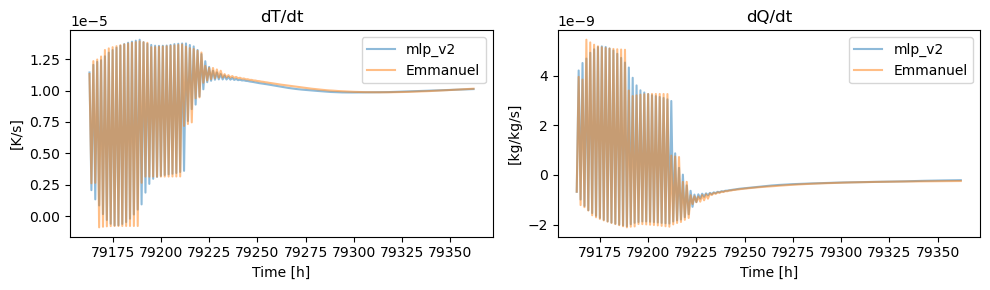

In [17]:
lev_idx = 10
sample_idx_1 = -700
sample_idx_2 = -500
fig = plt.figure(figsize=(10, 3))
ax = plt.subplot(1, 2, 1)
ax.plot(range(len(y_true_raw))[sample_idx_1:sample_idx_2], test_pred_raw[sample_idx_1:sample_idx_2, lev_idx].detach().numpy(), label=f"{model_name}",alpha=0.5)
ax.plot(range(len(y_true_raw))[sample_idx_1:sample_idx_2], y_true_raw[sample_idx_1:sample_idx_2, lev_idx].detach().numpy(), label="Emmanuel",alpha=0.5)
ax.set_title("dT/dt")
ax.set_xlabel("Time [h]")
ax.set_ylabel("[K/s]")
ax.legend()
ax = plt.subplot(1, 2, 2)
ax.plot(range(len(y_true_raw))[sample_idx_1:sample_idx_2], test_pred_raw[sample_idx_1:sample_idx_2, lev_idx+emulate_layer].detach().numpy(), label=f"{model_name}",alpha=0.5)
ax.plot(range(len(y_true_raw))[sample_idx_1:sample_idx_2], y_true_raw[sample_idx_1:sample_idx_2, lev_idx+emulate_layer].detach().numpy(), label="Emmanuel",alpha=0.5)
ax.set_title("dQ/dt")
ax.set_xlabel("Time [h]")
ax.set_ylabel("[kg/kg/s]")
ax.legend()
plt.tight_layout()

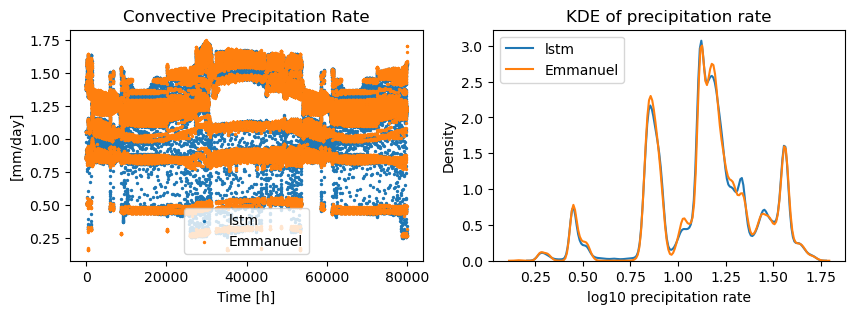

In [8]:
fig = plt.figure(figsize=(10, 3))
ax = plt.subplot(1, 2, 1)
ax.scatter(range(len(test_pred_raw[:, -1])),test_pred_raw[:, -1].detach().numpy(), label=f"{model_name}",s=2)
ax.scatter(range(len(test_pred_raw[:, -1])),y_true_raw[:, -1].detach().numpy(), label="Emmanuel",s=2)
ax.set_title("Convective Precipitation Rate")
ax.set_xlabel("Time [h]")
ax.set_ylabel("[mm/day]")
ax.legend()

ax = plt.subplot(1, 2, 2)
sns.kdeplot(test_pred_raw[:, -1].detach().numpy(), bw_adjust=0.5, label=f"{model_name}")
sns.kdeplot(y_true_raw[:, -1].detach().numpy(), bw_adjust=0.5, label="Emmanuel")
ax.set_xlabel("log10 precipitation rate")
ax.set_ylabel("Density")
ax.set_title("KDE of precipitation rate")
ax.legend()

Loading Tw = 5 from ./column_code_with_slab/best_model_conv_trsfm_v2_Tw_5/trial_17.pth


/projects/sds-lab/Shuochen/miniconda3/envs/ai/lib/python3.9/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loading Tw = 10 from ./column_code_with_slab/best_model_conv_trsfm_v2_Tw_10/trial_21.pth
Loading Tw = 15 from ./column_code_with_slab/best_model_conv_trsfm_v2_Tw_15/trial_21.pth
Loading Tw = 20 from ./column_code_with_slab/best_model_conv_trsfm_v2_Tw_20/trial_11.pth


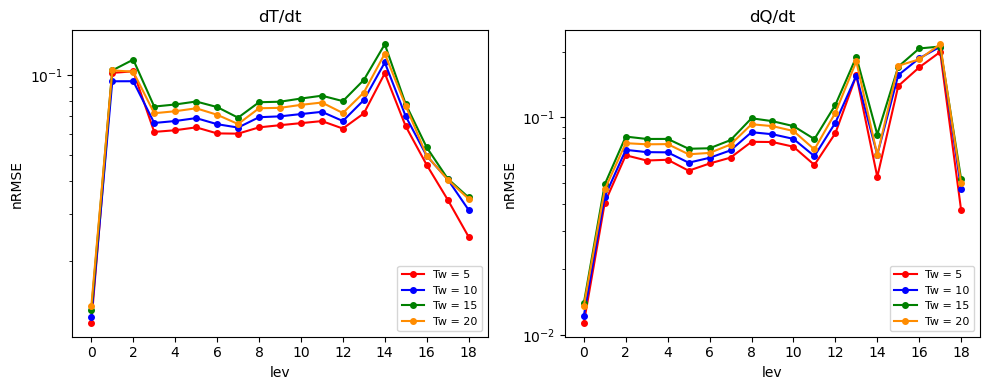


================ Normalized Model Performance (bottom 19 levels) ================
Model                    |    dT nMSE   dT nRMSE |    dQ nMSE   dQ nRMSE |     P nMSE    P nRMSE
Tw = 5                   |  4.462e-03  6.680e-02 |  8.843e-03  9.404e-02 |  2.543e-03  5.043e-02
Tw = 10                  |  4.934e-03  7.024e-02 |  1.027e-02  1.013e-01 |  2.971e-03  5.450e-02
Tw = 15                  |  6.502e-03  8.064e-02 |  1.283e-02  1.132e-01 |  3.984e-03  6.312e-02
Tw = 20                  |  5.736e-03  7.574e-02 |  1.167e-02  1.080e-01 |  3.540e-03  5.950e-02


In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset

sys.path.append("..")
from models import (
    DynamicMLP_flatten,
    DynamicMLP_flatten_v2,
    WindowTemporalLSTM,
    WindowTemporalTransformer_v2,
)

# =========================================================
# config
# =========================================================
exp_name = 'gmd_radiative_convective_1420w_10min_v3'
exp_folder_name = 'column_code_with_slab'
emulate = 'conv'
emulate_layer = 28
N = 19   # bottom N levels used for both plotting and summary metrics

model_runs = [
    # {"model_name": "mlp",    "best_trial_number": "0", "label": "MLP (unconstrained)", "color": "blue"},
    # {"model_name": "mlp_v2", "best_trial_number": "0", "label": "MLP (constrained)",   "color": "orange"},
    # {"model_name": "lstm",           "best_trial_number": "0",  "label": "LSTM",        "color": "green"},
    {"model_name": "trsfm_v2_Tw_5", "best_trial_number": "17", "label": "Tw = 5", "color": "red"},
    {"model_name": "trsfm_v2_Tw_10", "best_trial_number": "21", "label": "Tw = 10", "color": "blue"},
    {"model_name": "trsfm_v2_Tw_15", "best_trial_number": "21", "label": "Tw = 15", "color": "green"},
    {"model_name": "trsfm_v2_Tw_20", "best_trial_number": "11", "label": "Tw = 20", "color": "darkorange"}
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =========================================================
# dims
# =========================================================
if exp_folder_name == 'gmd_aquaplanet' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
elif exp_folder_name == 'gmd_aquaplanet' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59 - (28 - emulate_layer) * 2, 57 - (28 - emulate_layer) * 2
elif exp_folder_name == 'column_code_with_slab' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
elif exp_folder_name == 'column_code_with_slab' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59 - (28 - emulate_layer) * 2, 57 - (28 - emulate_layer) * 2
else:
    raise ValueError(f"Unsupported exp_folder_name={exp_folder_name}, emulate={emulate}")

# =========================================================
# load test data once
# =========================================================
X_test = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_test.pth",
    weights_only=True
)
y_test = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_test.pth",
    weights_only=True
)
norm = torch.load(
    f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth",
    weights_only=True
)

X_max = norm['X_max']
X_min = norm['X_min']
y_mean = norm['y_mean']
y_std  = norm['y_std']

X_den = (X_max - X_min).clone()
X_den[X_den == 0.0] = 1.0

y_std_safe = y_std.clone()
y_std_safe[y_std_safe == 0.0] = 1.0

X_test_n = (X_test - X_min) / X_den
y_test_n = (y_test - y_mean) / y_std_safe

# =========================================================
# helpers
# =========================================================
def make_windows_test(Xn, yn, Xraw, yraw, Tw):
    if Tw is None:
        raise ValueError("Tw is None.")
    if Tw < 1:
        raise ValueError(f"Tw must be >= 1, got {Tw}")
    if Xn.shape[0] < Tw:
        raise ValueError(f"N={Xn.shape[0]} is smaller than Tw={Tw}")

    Xn_w   = Xn.unfold(0, Tw, 1).permute(0, 2, 1).contiguous()
    Xraw_w = Xraw.unfold(0, Tw, 1).permute(0, 2, 1).contiguous()
    yn_w   = yn[Tw - 1:].contiguous()
    yraw_w = yraw[Tw - 1:].contiguous()
    return Xn_w, yn_w, Xraw_w, yraw_w


def build_model(model_name, ckpt):
    Tw = int(ckpt["T_window"]) if ("T_window" in ckpt) else None

    if model_name == "mlp":
        model = DynamicMLP_flatten(IN_FEATURES, OUT_FEATURES, ckpt["hidden_sizes"]).to(device)

    elif model_name == "mlp_v2":
        model = DynamicMLP_flatten_v2(IN_FEATURES, OUT_FEATURES, ckpt["hidden_sizes"]).to(device)

    elif model_name == "lstm":
        model = WindowTemporalLSTM(
            C_in=IN_FEATURES,
            C_out=OUT_FEATURES,
            T_window=Tw,
            hidden_size=ckpt["hidden_size"],
            num_layers=ckpt["num_layers"],
            dropout=ckpt["dropout"],
            nlev=int(ckpt.get("nlev", emulate_layer)),
        ).to(device)

    elif "trsfm_v2" in model_name:
        model = WindowTemporalTransformer_v2(
            C_in=IN_FEATURES,
            C_out=OUT_FEATURES,
            T_window=Tw,
            d_model=ckpt["d_model"],
            nhead=ckpt["nhead"],
            num_layers=ckpt["num_layers"],
            dim_feedforward=ckpt["dim_feedforward"],
            dropout=ckpt["dropout"],
            causal=True,
            nlev=int(ckpt.get("nlev", emulate_layer)),
            clamp_from_level=ckpt.get("clamp_from_level", None),
            input_clamp_from_level=ckpt.get("input_clamp_from_level", None),
        ).to(device)

    else:
        raise ValueError(f"Unknown model_name={model_name}")

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, Tw


def build_test_loader(model_name, batch_size, Tw):
    if "mlp" in model_name:
        test_set = TensorDataset(X_test_n, y_test_n, X_test, y_test)
        test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, drop_last=False)

    elif ("lstm" in model_name) or ("trsfm" in model_name):
        if Tw is None:
            raise ValueError(f"{model_name} checkpoint missing T_window.")
        Xw_test_n, yw_test_n, Xw_test, yw_test = make_windows_test(
            X_test_n, y_test_n, X_test, y_test, Tw
        )
        test_set = TensorDataset(Xw_test_n, yw_test_n, Xw_test, yw_test)
        test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, drop_last=False)

    else:
        raise ValueError(f"Unknown model_name={model_name}")

    return test_loader


def run_inference(model, test_loader):
    pred_n_list = []
    yraw_list = []

    with torch.no_grad():
        for Xn, yn, Xraw, yraw in test_loader:
            Xn = Xn.to(device)
            y_pred_n = model(Xn)

            pred_n_list.append(y_pred_n.cpu())
            yraw_list.append(yraw.cpu())

    test_pred_n = torch.cat(pred_n_list, dim=0)
    y_true_raw  = torch.cat(yraw_list, dim=0)

    test_pred_raw = test_pred_n * y_std_safe + y_mean
    return y_true_raw.numpy(), test_pred_raw.numpy()


def compute_normalized_variable_errors_bottomN(y_true, y_pred, N):
    """
    Normalized MSE / RMSE for bottom N levels only:
      - dT/dt: bottom N levels
      - dQ/dt: bottom N levels
      - precip: full scalar variable
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    dT_true = y_true[:, :28][:, :N]
    dT_pred = y_pred[:, :28][:, :N]

    dQ_true = y_true[:, 28:56][:, :N]
    dQ_pred = y_pred[:, 28:56][:, :N]

    P_true = y_true[:, 56]
    P_pred = y_pred[:, 56]

    std_floor_dT = 1e-8
    std_floor_dQ = 1e-12
    std_floor_P  = 1e-8

    mean_dT = np.mean(dT_true, axis=0, dtype=np.float64)
    std_dT  = np.std(dT_true, axis=0, dtype=np.float64)
    std_dT_safe = np.maximum(std_dT, std_floor_dT)

    dT_true_z = (dT_true - mean_dT) / std_dT_safe
    dT_pred_z = (dT_pred - mean_dT) / std_dT_safe

    mean_dQ = np.mean(dQ_true, axis=0, dtype=np.float64)
    std_dQ  = np.std(dQ_true, axis=0, dtype=np.float64)
    std_dQ_safe = np.maximum(std_dQ, std_floor_dQ)

    dQ_true_z = (dQ_true - mean_dQ) / std_dQ_safe
    dQ_pred_z = (dQ_pred - mean_dQ) / std_dQ_safe

    mean_P = np.mean(P_true, dtype=np.float64)
    std_P  = np.std(P_true, dtype=np.float64)
    std_P_safe = max(std_P, std_floor_P)

    P_true_z = (P_true - mean_P) / std_P_safe
    P_pred_z = (P_pred - mean_P) / std_P_safe

    nmse_dT = np.mean((dT_true_z - dT_pred_z) ** 2, dtype=np.float64)
    nmse_dQ = np.mean((dQ_true_z - dQ_pred_z) ** 2, dtype=np.float64)
    nmse_P  = np.mean((P_true_z - P_pred_z) ** 2, dtype=np.float64)

    nrmse_dT = np.sqrt(nmse_dT)
    nrmse_dQ = np.sqrt(nmse_dQ)
    nrmse_P  = np.sqrt(nmse_P)

    return nmse_dT, nrmse_dT, nmse_dQ, nrmse_dQ, nmse_P, nrmse_P


def compute_standardized_nrmse_profiles(y_true, y_pred):
    """
    Per-level standardized nRMSE profiles for plotting.
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    dT_true = y_true[:, :28]
    dT_pred = y_pred[:, :28]

    dQ_true = y_true[:, 28:56]
    dQ_pred = y_pred[:, 28:56]

    std_floor_dT = 1e-8
    std_floor_dQ = 1e-16

    mean_dT = np.mean(dT_true, axis=0, dtype=np.float64)
    std_dT  = np.std(dT_true, axis=0, dtype=np.float64)
    std_dT_safe = np.maximum(std_dT, std_floor_dT)

    mean_dQ = np.mean(dQ_true, axis=0, dtype=np.float64)
    std_dQ  = np.std(dQ_true, axis=0, dtype=np.float64)
    std_dQ_safe = np.maximum(std_dQ, std_floor_dQ)

    # global_std = np.std(dT_true)
    # dT_true_z = (dT_true - mean_dT) / global_std
    # dT_pred_z = (dT_pred - mean_dT) / global_std
    dT_true_z = (dT_true - mean_dT) / std_dT_safe
    dT_pred_z = (dT_pred - mean_dT) / std_dT_safe

    # global_std = np.std(dQ_true)
    # dQ_true_z = (dQ_true - mean_dQ) / global_std
    # dQ_pred_z = (dQ_pred - mean_dQ) / global_std
    dQ_true_z = (dQ_true - mean_dQ) / std_dQ_safe
    dQ_pred_z = (dQ_pred - mean_dQ) / std_dQ_safe

    rmse_dT_z = np.sqrt(np.mean((dT_true_z - dT_pred_z) ** 2, axis=0, dtype=np.float64))
    rmse_dQ_z = np.sqrt(np.mean((dQ_true_z - dQ_pred_z) ** 2, axis=0, dtype=np.float64))

    return rmse_dT_z, rmse_dQ_z


# =========================================================
# run all models
# =========================================================
results = []

for run_cfg in model_runs:
    model_name = run_cfg["model_name"]
    best_trial_number = run_cfg["best_trial_number"]
    label = run_cfg.get("label", f"{model_name} (trial {best_trial_number})")

    ml_exp_name = 'best_model' + '_' + emulate + '_' + model_name
    best_model_path = f"./{exp_folder_name}/{ml_exp_name}/trial_{best_trial_number}.pth"

    if not os.path.exists(best_model_path):
        print(f"Skipping missing checkpoint: {best_model_path}")
        continue

    print(f"Loading {label} from {best_model_path}")

    ckpt = torch.load(best_model_path, map_location="cpu")
    batch_size = ckpt["batch_size"]

    model, Tw = build_model(model_name, ckpt)
    test_loader = build_test_loader(model_name, batch_size, Tw)
    y_true, y_pred = run_inference(model, test_loader)

    nmse_dT, nrmse_dT, nmse_dQ, nrmse_dQ, nmse_P, nrmse_P = compute_normalized_variable_errors_bottomN(
        y_true, y_pred, N
    )
    nrmse_dT_z, nrmse_dQ_z = compute_standardized_nrmse_profiles(y_true, y_pred)

    results.append({
        "label": label,
        "color": run_cfg["color"],
        "nmse_dT": nmse_dT,
        "nrmse_dT": nrmse_dT,
        "nmse_dQ": nmse_dQ,
        "nrmse_dQ": nrmse_dQ,
        "nmse_P": nmse_P,
        "nrmse_P": nrmse_P,
        "nrmse_dT_z": nrmse_dT_z,
        "nrmse_dQ_z": nrmse_dQ_z,
    })

if len(results) == 0:
    raise RuntimeError("No valid model results found.")

# =========================================================
# plot all on same figure
# =========================================================
levels = np.arange(28)
levels_plot = levels[:N]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for res in results:
    axs[0].plot(
        levels_plot,
        res["nrmse_dT_z"][:N],
        marker='o',
        color=res["color"],
        label=res["label"],
        markersize=4
    )
    axs[1].plot(
        levels_plot,
        res["nrmse_dQ_z"][:N],
        marker='o',
        color=res["color"],
        label=res["label"],
        markersize=4
    )

axs[0].set_yscale('log')
axs[0].set_xticks(levels_plot[::2])
axs[0].set_title('dT/dt')
axs[0].set_xlabel('lev')
axs[0].set_ylabel('nRMSE')
axs[0].legend(fontsize=8, loc='lower right')

axs[1].set_yscale('log')
axs[1].set_xticks(levels_plot[::2])
axs[1].set_title('dQ/dt')
axs[1].set_xlabel('lev')
axs[1].set_ylabel('nRMSE')
axs[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
# plt.savefig('figs/four_models_lev_nrmse_trsfm.png')
plt.show()

# =========================================================
# summary table
# =========================================================
print(f"\n================ Normalized Model Performance (bottom {N} levels) ================")
print(f"{'Model':24s} | {'dT nMSE':>10s} {'dT nRMSE':>10s} | {'dQ nMSE':>10s} {'dQ nRMSE':>10s} | {'P nMSE':>10s} {'P nRMSE':>10s}")
for r in results:
    print(
        f"{r['label']:24s} | "
        f"{r['nmse_dT']:10.3e} {r['nrmse_dT']:10.3e} | "
        f"{r['nmse_dQ']:10.3e} {r['nrmse_dQ']:10.3e} | "
        f"{r['nmse_P']:10.3e} {r['nrmse_P']:10.3e}"
    )

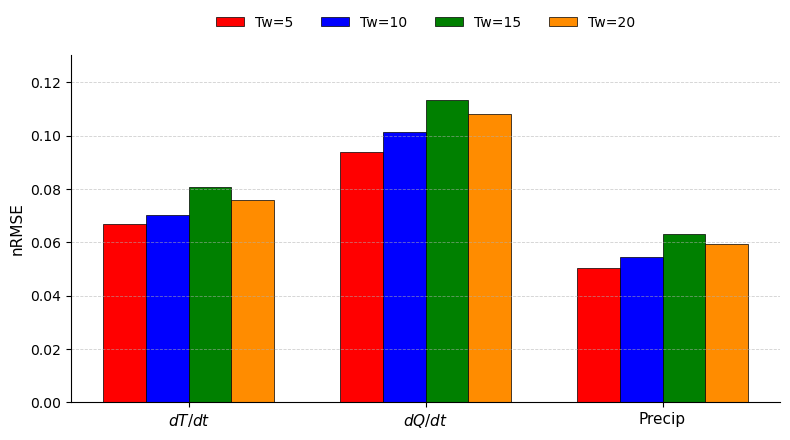

In [4]:
# =========================================================
# paper-quality grouped bar plot
# =========================================================
vals = {
    # "MLP (unconstrained)": [results[0]["nrmse_dT"], results[0]["nrmse_dQ"], results[0]["nrmse_P"]],
    # "MLP (constrained)":   [results[1]["nrmse_dT"], results[1]["nrmse_dQ"], results[1]["nrmse_P"]],
    # "LSTM":                [results[2]["nrmse_dT"], results[2]["nrmse_dQ"], results[2]["nrmse_P"]],
    # "Transformer":         [results[3]["nrmse_dT"], results[3]["nrmse_dQ"], results[3]["nrmse_P"]],
    "Tw=5":         [results[0]["nrmse_dT"], results[0]["nrmse_dQ"], results[0]["nrmse_P"]],
    "Tw=10":         [results[1]["nrmse_dT"], results[1]["nrmse_dQ"], results[1]["nrmse_P"]],
    "Tw=15":         [results[2]["nrmse_dT"], results[2]["nrmse_dQ"], results[2]["nrmse_P"]],
    "Tw=20":         [results[3]["nrmse_dT"], results[3]["nrmse_dQ"], results[3]["nrmse_P"]],
}


variables = [r"$dT/dt$", r"$dQ/dt$", "Precip"]
model_names = list(vals.keys())
n_models = len(model_names)

x = np.arange(len(variables))
width = 0.18

# colorblind-friendly palette
colors = ["red", "blue", "green", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 4.5))

# bars
for i, model in enumerate(model_names):
    ax.bar(
        x + (i - (n_models - 1)/2) * width,
        vals[model],
        width,
        label=model,
        color=colors[i],
        edgecolor='black',
        linewidth=0.5
    )

# formatting
ax.set_xticks(x)
ax.set_xticklabels(variables, fontsize=11)
ax.set_ylabel("nRMSE", fontsize=11)

# grid (horizontal only → cleaner)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)

# tighten y-limits slightly for better contrast
ymax = max([max(v) for v in vals.values()])
ax.set_ylim(0, ymax * 1.15)

# legend on top (paper style)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=n_models,
    frameon=False,
    fontsize=10
)

# remove top/right spines (clean style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    'figs/four_models_nrmse_trsfm.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## rad

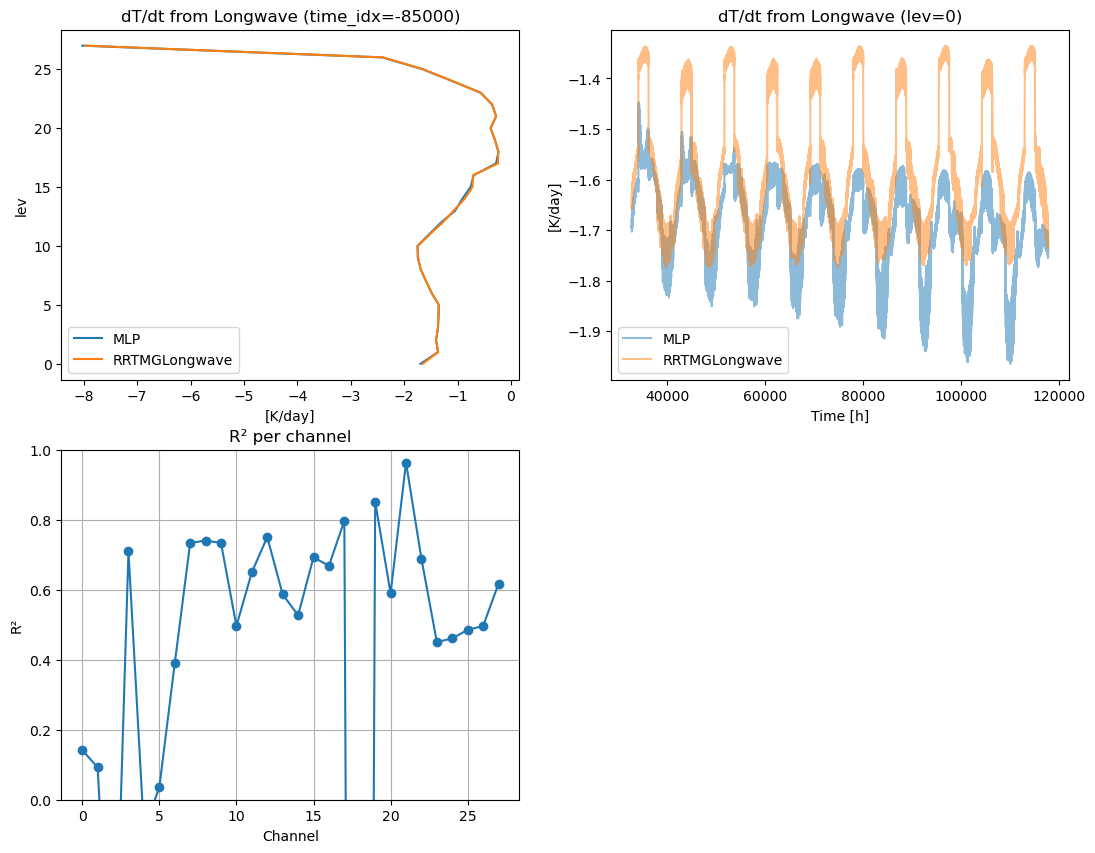

In [16]:
lev_idx = 0
time_idx = -85000
fig = plt.figure(figsize=(13, 10))
ax = plt.subplot(2, 2, 1)
ax.plot(test_pred[time_idx, :28].detach().numpy(), range(28), label="MLP")
ax.plot(y_test[time_idx, :28].detach().numpy(), range(28), label="RRTMGLongwave")
ax.set_title(f"dT/dt from Longwave (time_idx={time_idx})")
ax.set_xlabel("[K/day]")
ax.set_ylabel("lev")
ax.legend()

ax = plt.subplot(2, 2, 2)
ax.plot(range(len(y_test))[time_idx:], test_pred[time_idx:, lev_idx].detach().numpy(), label="MLP",alpha=0.5)
ax.plot(range(len(y_test))[time_idx:], y_test[time_idx:, lev_idx].detach().numpy(), label="RRTMGLongwave",alpha=0.5)
ax.set_title(f"dT/dt from Longwave (lev={lev_idx})")
ax.set_xlabel("Time [h]")
ax.set_ylabel("[K/day]")
ax.legend()

# y_pred, y_test: [B, C]
ax = plt.subplot(2, 2, 3)
ss_res = ((y_test - test_pred) ** 2).sum(dim=0)
ss_tot = ((y_test - y_test.mean(dim=0)) ** 2).sum(dim=0)
r2 = 1 - ss_res / ss_tot    # shape: [C]
eps = 1e-8
r2 = 1 - ss_res / (ss_tot + eps)
ax.plot(range(r2.numel()), r2.cpu().numpy(), marker='o')
ax.set_ylim(0,1)
ax.set_xlabel("Channel")
ax.set_ylabel("R²")
ax.set_title("R² per channel")
ax.grid(True)

# multi-column

## rad

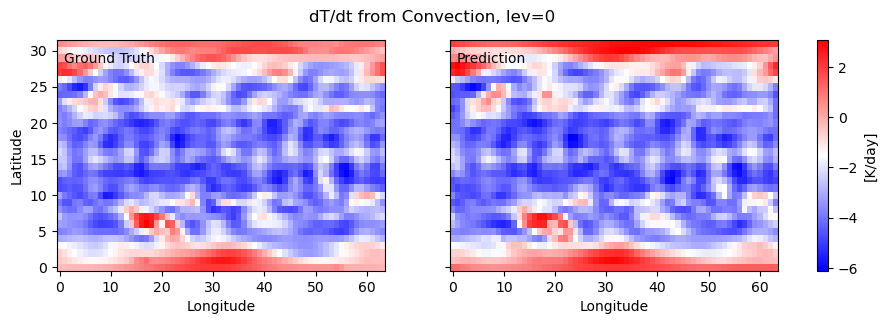

In [41]:
# longwave heating rate
lev=0
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,lev,:,:], origin='lower', aspect='auto', cmap='bwr')
im1=axes[1].imshow(test_pred[-1,lev,:,:], origin='lower', aspect='auto', cmap='bwr')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.suptitle(f'dT/dt from Longwave, lev={lev}')
fig.colorbar(im1, ax=axes, label='[K/day]', fraction=0.02)

## conv

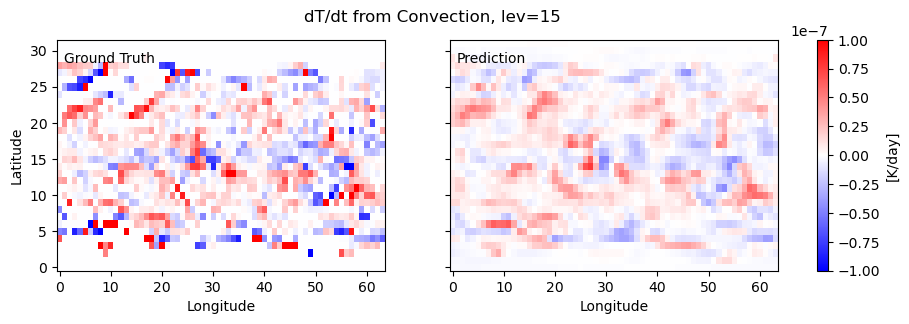

In [18]:
lev=15
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,lev,:,:], origin='lower', aspect='auto', vmin=-1e-7, vmax=1e-7,cmap='bwr')
im1=axes[1].imshow(test_pred[-1,lev,:,:], origin='lower', aspect='auto', vmin=-1e-7, vmax=1e-7,cmap='bwr')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.suptitle(f'dT/dt from Convection, lev={lev}')
fig.colorbar(im1, ax=axes, label='[K/day]', fraction=0.02)

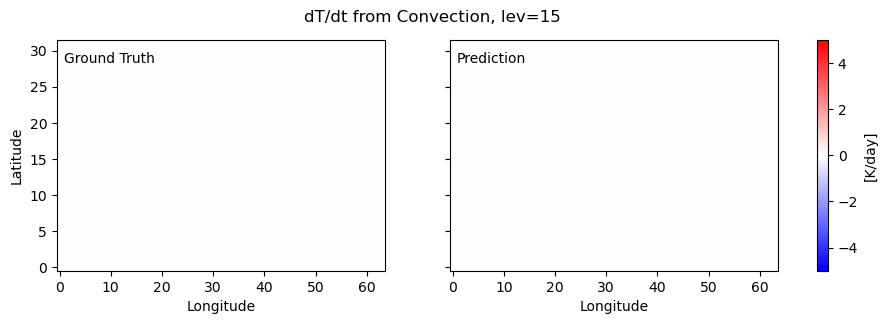

In [14]:
lev=15
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,lev,:,:], origin='lower', aspect='auto', vmin=-5, vmax=5,cmap='bwr')
im1=axes[1].imshow(test_pred[-1,lev,:,:], origin='lower', aspect='auto', vmin=-5, vmax=5,cmap='bwr')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.suptitle(f'dT/dt from Convection, lev={lev}')
fig.colorbar(im1, ax=axes, label='[K/day]', fraction=0.02)

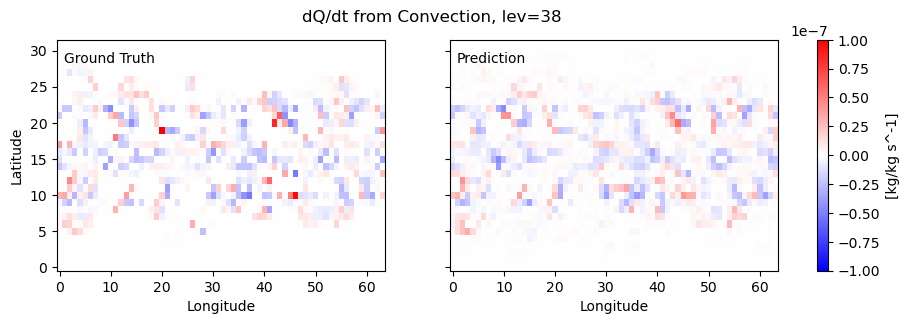

In [10]:
lev=28+10
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,lev,:,:], origin='lower', aspect='auto', vmin=-1e-7, vmax=1e-7,cmap='bwr')
im1=axes[1].imshow(test_pred[-1,lev,:,:], origin='lower', aspect='auto', vmin=-1e-7, vmax=1e-7,cmap='bwr')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.suptitle(f'dQ/dt from Convection, lev={lev}')
fig.colorbar(im1, ax=axes, label='[kg/kg s^-1]', fraction=0.02)

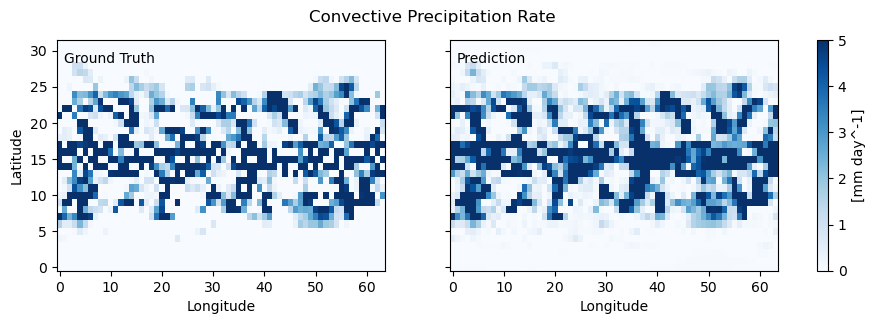

In [9]:
lev=-1
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,lev,:,:], origin='lower', aspect='auto', vmin=0, vmax=5,cmap='Blues')
im1=axes[1].imshow(test_pred[-1,lev,:,:], origin='lower', aspect='auto', vmin=0, vmax=5,cmap='Blues')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.suptitle(f'Convective Precipitation Rate')
fig.colorbar(im1, ax=axes, label='[mm day^-1]', fraction=0.02)

Text(0, 0.5, 'lev')

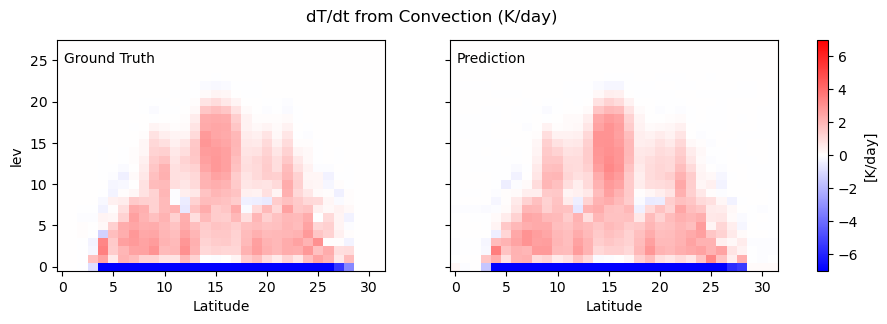

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,:28,:,:].mean(dim=-1), origin='lower',aspect='auto', vmin=-7, vmax=7,cmap='bwr')
im1=axes[1].imshow(test_pred[-1,:28,:,:].mean(dim=-1), origin='lower', aspect='auto', vmin=-7, vmax=7,cmap='bwr')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
plt.suptitle(f'dT/dt from Convection (K/day)')
fig.colorbar(im1, ax=axes, label='[K/day]', fraction=0.02)
axes[0].set_xlabel('Latitude')
axes[1].set_xlabel('Latitude')
axes[0].set_ylabel('lev')

Text(0, 0.5, 'lev')

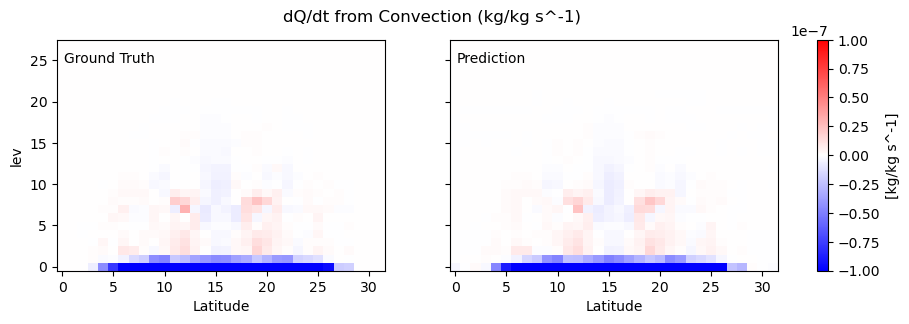

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
im0=axes[0].imshow(y_test[-1,28:56,:,:].mean(dim=-1), origin='lower',aspect='auto', vmin=-1e-7, vmax=1e-7,cmap='bwr')
im1=axes[1].imshow(test_pred[-1,28:56,:,:].mean(dim=-1), origin='lower', aspect='auto', vmin=-1e-7, vmax=1e-7,cmap='bwr')
axes[0].text(0.02, 0.95, 'Ground Truth',transform=axes[0].transAxes,ha='left', va='top',color='black',fontsize=10)
axes[1].text(0.02, 0.95, 'Prediction',transform=axes[1].transAxes,ha='left', va='top',color='black',fontsize=10)
plt.suptitle(f'dQ/dt from Convection (kg/kg s^-1)')
fig.colorbar(im1, ax=axes, label='[kg/kg s^-1]', fraction=0.02)
axes[0].set_xlabel('Latitude')
axes[1].set_xlabel('Latitude')
axes[0].set_ylabel('lev')

In [7]:
loss=nn.MSELoss()
loss(test_pred,y_test)

tensor(0.9350)

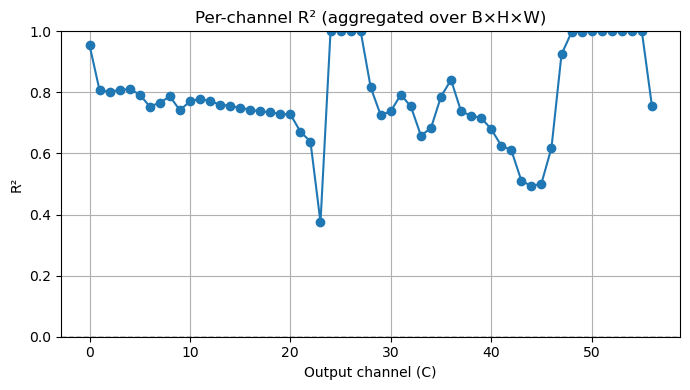

In [8]:
B, C, H, W = y_test.shape
y_true = y_test.permute(1, 0, 2, 3).reshape(C, -1)
y_pred = test_pred.permute(1, 0, 2, 3).reshape(C, -1)
r2 = torch.zeros(C, device=y_test.device)
for c in range(C):
    mask = ~torch.isnan(y_true[c])
    yt = y_true[c, mask]
    yp = y_pred[c, mask]
    ss_res = ((yt - yp) ** 2).sum()
    ss_tot = ((yt - yt.mean()) ** 2).sum()
    r2[c] = 1.0 - ss_res / (ss_tot + 1e-12)
plt.figure(figsize=(7, 4))
plt.plot(r2.cpu().numpy(), marker='o')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Output channel (C)")
plt.ylabel("R²")
plt.ylim(0.0,1)
plt.title("Per-channel R² (aggregated over B×H×W)")
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Spatial R² (channel 15)')

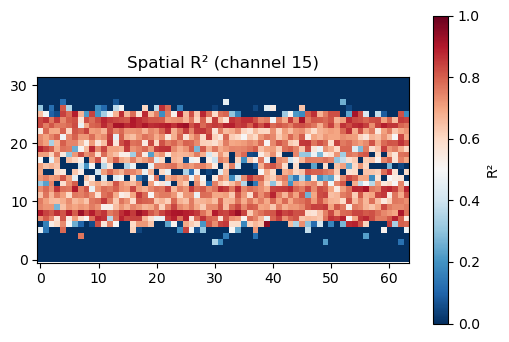

In [15]:
c = 15
y_true = y_test[:, c, :, :]      # [B, H, W]
y_pred = test_pred[:, c, :, :]   # [B, H, W]
# Mask NaNs (very important)
mask = ~torch.isnan(y_true)
# Mean over B at each grid point
y_mean = torch.nanmean(y_true, dim=0)   # [H, W]
# Residual sum of squares
ss_res = torch.nansum((y_true - y_pred) ** 2, dim=0)
# Total sum of squares
ss_tot = torch.nansum((y_true - y_mean) ** 2, dim=0)
# R² map
r2_map = 1.0 - ss_res / (ss_tot + 1e-12)

plt.figure(figsize=(6, 4))
plt.imshow(r2_map.cpu(), origin="lower", cmap="RdBu_r", vmin=0.0, vmax=1)
plt.colorbar(label="R²")
plt.title(f"Spatial R² (channel {c})")

tensor(0.0039)


In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import optuna
import sys,os
sys.path.append("..")
import numpy as np
import random
import seaborn as sns
from models import DynamicMLP, DynamicMLP_flatten, DynamicMLP_flatten_maskq, FlatTemporalTransformer, FlatTemporalTransformer2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

exp_name = 'gmd_radiative_convective_1420w_10min_v3' #'gmd_radiative_convective_1420w_10min' '64x32_4h_400w'
exp_folder_name =  'column_code_with_slab' #'column_code_with_slab' 'gmd_aquaplanet'
model_name = 'trsfm' # 'trsfm' 'mlp'
emulate = 'conv' # 'conv' 'rad'
emulate_layer = 15
ml_exp_name = 'best_model'+ '_' + emulate + '_' + model_name
best_model_path = f"./{exp_folder_name}/{ml_exp_name}/trial_1955.pth"

if exp_folder_name == 'gmd_aquaplanet' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28
if exp_folder_name == 'gmd_aquaplanet' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59-(28-emulate_layer)*2, 57-(28-emulate_layer)*2
if exp_folder_name == 'column_code_with_slab' and emulate == 'rad':
    IN_FEATURES, OUT_FEATURES = 59, 28 #59 if cloudbasemassflux
if exp_folder_name == 'column_code_with_slab' and emulate == 'conv':
    IN_FEATURES, OUT_FEATURES = 59-(28-emulate_layer)*2, 57-(28-emulate_layer)*2 #59 if cloudbasemassflux
BATCH_SIZE = torch.load(best_model_path)['batch_size']


X_test = torch.load(f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_test.pth", weights_only=True)
y_test = torch.load(f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_test.pth", weights_only=True)
norm = torch.load(f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth", weights_only=True)
# normalization
X_mean = norm['X_mean'] # [C]
X_std  = norm['X_std']
X_max  = norm['X_max']
X_min  = norm['X_min']
y_mean = norm['y_mean']
y_std  = norm['y_std']
y_max  = norm['y_max']
y_min  = norm['y_min']

X_std_safe = X_std.clone()
X_std_safe[X_std_safe == 0.0] = 1.0
y_std_safe = y_std.clone()
y_std_safe[y_std_safe == 0.0] = 1.0

X_den = (X_max - X_min).clone()
X_den[X_den == 0.0] = 1.0
y_den = (y_max - y_min).clone()
y_den[y_den == 0.0] = 1.0

X_test_n = X_test.clone()
y_test_n = y_test.clone()

X_test_n = (X_test - X_min) / X_den
y_test_n = (y_test - y_mean) / y_std_safe

# create datasets
test_set = TensorDataset(X_test_n, y_test_n, X_test, y_test)
# create dataloaders
test_dataloader = DataLoader(test_set,batch_size=BATCH_SIZE,shuffle=False)
# load model
if model_name == 'mlp':
    ckpt = torch.load(best_model_path)
    model = DynamicMLP_flatten(IN_FEATURES,OUT_FEATURES,ckpt["hidden_sizes"]).to(device)
    # model = DynamicMLP_flatten_maskq(IN_FEATURES,OUT_FEATURES,ckpt["hidden_sizes"]).to(device)
    model.load_state_dict(ckpt["model_state"])
if model_name == 'trsfm':
    ckpt = torch.load(best_model_path)
    model=FlatTemporalTransformer2(C_in=IN_FEATURES,
        C_out=OUT_FEATURES,
        T_window=ckpt["T_window"],
        d_model=ckpt["d_model"],
        nhead=ckpt["nhead"],
        num_layers=ckpt["num_layers"],
        dim_feedforward=ckpt["dim_feedforward"],
        dropout=ckpt["dropout"]).to(device)
    model.load_state_dict(ckpt["model_state"])
    
# inference
test_pred = []
with torch.no_grad():
    for Xn, yn, X, y in test_dataloader:
        Xn, yn, X, y = Xn.to(device), yn.to(device), X.to(device), y.to(device)
        # y_pred = model(Xn.to(device), q_raw=X[:, 28:56])
        y_pred = model(Xn.to(device))
        test_pred.append(y_pred.cpu())
test_pred = torch.cat(test_pred, dim=0)
# # original scale and units
test_pred = test_pred * y_std_safe + y_mean
# test_pred = inv_log_transform(test_pred, eps=1e-12, scale=10.0)
# test_pred = test_pred * y_den + y_min

loss_fn = nn.MSELoss()
print(loss_fn(y_test,test_pred))

# to four dim to plot for multi-col
if exp_folder_name == 'gmd_aquaplanet':
    H, W = 32, 64
    B = X_test.shape[0] // H // W
    X_test = X_test.reshape(B, H, W, IN_FEATURES).permute(0, 3, 1, 2)
    y_test = y_test.reshape(B, H, W, OUT_FEATURES).permute(0, 3, 1, 2)
    test_pred = test_pred.reshape(B, H, W, OUT_FEATURES).permute(0, 3, 1, 2)

In [ ]:
def log_transform(x, eps, scale):
    return torch.sign(x) * torch.log1p(torch.abs(x) / eps) / scale
def inv_log_transform(x_n, eps, scale):
    # inverse of sign(x)*log1p(|x|/eps)/10
    return torch.sign(x_n) * torch.expm1(torch.abs(x_n) * scale) * eps# X_std_safe = X_std.clone()

# X_std_safe[X_std_safe == 0.0] = 1.0

# X_test_n[:, :28] /= 300 # (X_train[:, :28] - X_mean[:28]) / X_std_safe[:28]
# X_test_n[:, 28:56] = log_transform(X_test[:, 28:56], eps=1e-12, scale=10.0)
# X_test_n[:, 28:56] /= 1e-2
# X_test_n[:, 28:56] = torch.log1p(torch.clamp(X_test[:, 28:56], min=1e-8) / 1e-8) / 5
# X_test_n[:, -2] /= 10# (X_train[:, -2] - X_mean[-2]) / X_std_safe[-2]
# X_test_n[:, -1] # (X_train[:, -1] - X_mean[-1]) / X_std_safe[-1]

# X_test_n[:, 28:56] = (X_test[:, 28:56] - X_min[28:56]) / den[28:56]
# X_test_n[:, :28] = (X_test[:, :28] - X_min[:28]) / den[:28]
# X_test_n[:, :28] = log_transform(X_test_n[:, :28], eps=1e-12, scale=10.0)
# X_test_n[:, :28] /= 300
# X_test_n[:, -2] = (X_test[:, -2] - X_mean[-2]) / X_std_safe[-2]
# X_test_n[:, -1] = (X_test[:, -1] - X_mean[-1]) / X_std_safe[-1]
# X_test_n[:, -2] = (X_test[:, -2] - X_min[-2]) / den[-2]
# X_test_n[:, -1] = (X_test[:, -1] - X_min[-1]) / den[-1]
# X_test_n[:, -2] = log_transform(X_test[:, -2], eps=1e-12, scale=10.0)
# X_test_n[:, -1] = log_transform(X_test[:, -1], eps=1e-12, scale=10.0)
# X_test_n[:, -2] /= 10
# X_test_n[:, -1] /= 3

# good online
# X_test_n = log_transform(X_test, eps=1e-12, scale=10.0)
# y_test_n = log_transform(y_test, eps=1e-12, scale=10.0)
    
# X_std_safe = X_std.clone()
# X_std_safe[X_std_safe == 0.0] = 1.0
# X_test_n = X_test.clone()
# X_test_n[:, :28] = (X_test[:, :28] - X_mean[:28]) / X_std_safe[:28]
# X_test_n[:, 28:56] = log_transform(X_test[:, 28:56])
# X_test_n[:, -3] = (X_test[:, -3] - X_mean[-3]) / X_std_safe[-3]
# X_test_n[:, -2] = (X_test[:, -2] - X_mean[-2]) / X_std_safe[-2]
# X_test_n[:, -1] = (X_test[:, -1] - X_mean[-1]) / X_std_safe[-1]
